# Exploring the data 

Load in all of the data and rasters that we have from the previous step. 

We'll focus on just the lowman data for now. 

In [11]:
import numpy as np

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

In [2]:
data_dir = '../data/' # on local machine
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
data_file = 'stacks/mores_creek/'

data = xr.open_zarr(data_dir + data_file)
# drop crs data var
data = data.drop_vars('crs')
print(data.data_vars)

Data variables:
    acq_day_precip      (pair, y, x) float64 9MB dask.array<chunksize=(21, 25, 25), meta=np.ndarray>
    aspect              (y, x) float32 212kB dask.array<chunksize=(25, 25), meta=np.ndarray>
    canopy_2019         (y, x) float32 212kB dask.array<chunksize=(25, 25), meta=np.ndarray>
    coherence           (flight_id, pair, y, x) float32 4MB dask.array<chunksize=(1, 21, 25, 25), meta=np.ndarray>
    cover_2019          (y, x) float64 423kB dask.array<chunksize=(25, 25), meta=np.ndarray>
    curve               (y, x) float32 212kB dask.array<chunksize=(25, 25), meta=np.ndarray>
    density_change      (pair, y, x) float32 4MB dask.array<chunksize=(21, 25, 25), meta=np.ndarray>
    diurnal_temp_range  (pair, y, x) float64 9MB dask.array<chunksize=(21, 25, 25), meta=np.ndarray>
    elevation           (y, x) float32 212kB dask.array<chunksize=(25, 25), meta=np.ndarray>
    freeze_thaw_cycles  (pair, y, x) float64 9MB dask.array<chunksize=(21, 25, 25), meta=np.ndarray>


In [5]:
# nan mask 
nan_mask = np.isnan(data['coherence'].values).any(axis=(0,1))  # axis=0 is the 'pair' dimension

# Now apply it universally to all variables
for var in data.data_vars:
    if 'x' in data[var].dims and 'y' in data[var].dims:
        print(var)
        data[var] = data[var].where(~nan_mask, drop=False)

acq_day_precip
aspect
canopy_2019
coherence
cover_2019
curve
density_change
diurnal_temp_range
elevation
freeze_thaw_cycles
hours_blowing_snow
incidence_angle
max_temp
max_wind
mean_temp
mean_wind
slope
snow_class
swe_ablate
swe_accum
temp_diff
temp_diff_acq
total_posdeg
total_precip
total_rain
total_snow


Static variables: ['aspect', 'canopy_2019', 'cover_2019', 'curve', 'elevation', 'incidence_angle', 'slope', 'snow_class']
Pair variables: ['acq_day_precip', 'coherence', 'density_change', 'diurnal_temp_range', 'freeze_thaw_cycles', 'hours_blowing_snow', 'max_temp', 'max_wind', 'mean_temp', 'mean_wind', 'swe_ablate', 'swe_accum', 'temp_diff', 'temp_diff_acq', 'total_posdeg', 'total_precip', 'total_rain', 'total_snow']


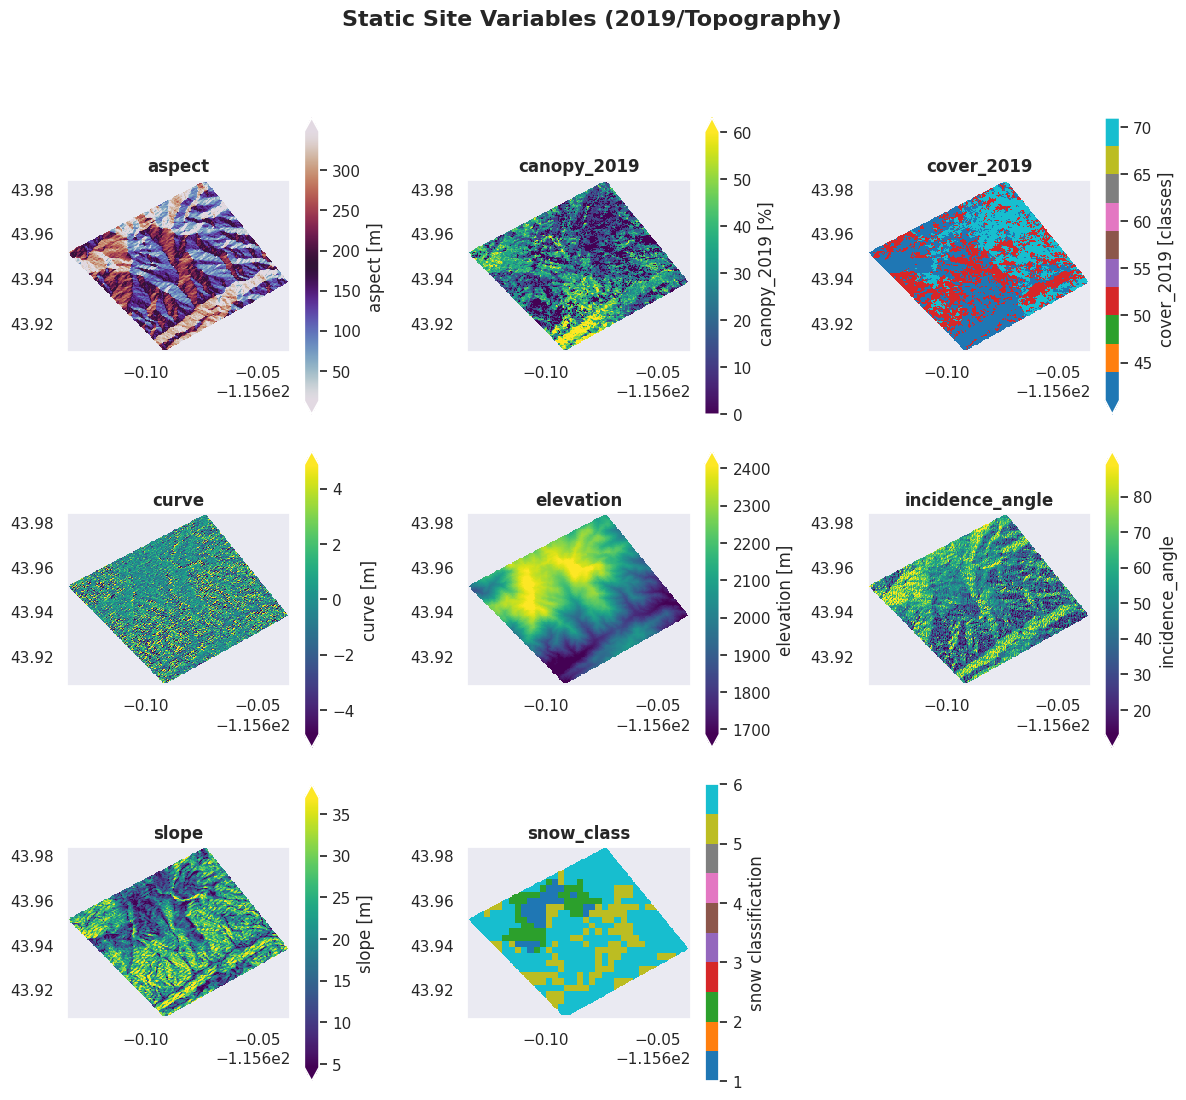

In [6]:
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
print("Static variables:", static_vars)
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]
print("Pair variables:", pair_vars)

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [7]:
# 3. Flatten into ML-ready format
data_array = data.to_array(dim='variable')  # (variable, pair, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

,acq_day_precip,aspect,canopy_2019,coherence,cover_2019,curve,density_change,diurnal_temp_range,elevation,freeze_thaw_cycles,hours_blowing_snow,incidence_angle,max_temp,max_wind,mean_temp,mean_wind,slope,snow_class,swe_ablate,swe_accum,temp_diff,temp_diff_acq,total_posdeg,total_precip,total_rain,total_snow
acq_day_precip,1.000000,0.003034,-0.004976,-0.011648,-0.000491,0.000065,0.136121,-0.295334,0.039055,-0.011222,0.371919,0.012657,-0.204583,0.408322,-0.378779,0.276619,-0.012432,-0.021902,-0.045943,0.446548,-0.170764,-0.185753,-0.086681,0.459775,-0.141944,0.490800
aspect,0.003034,1.000000,0.251503,-0.071346,-0.242441,0.013202,0.018126,-0.028172,-0.022698,0.003318,0.013616,0.376986,-0.002356,0.042820,-0.002849,0.042942,0.071228,-0.010868,0.059888,0.045834,-0.002222,0.002813,0.008707,0.006612,-0.004514,0.007570
canopy_2019,-0.004976,0.251503,1.000000,-0.111594,-0.544309,0.035204,0.020998,0.000328,-0.234993,0.056225,-0.109480,0.269065,0.046492,-0.078836,0.084537,-0.097933,0.093633,0.122605,0.045999,0.000247,-0.012259,-0.023976,0.069622,-0.005072,0.077334,-0.021074
coherence,-0.011648,-0.071346,-0.111594,1.000000,0.136446,0.003440,-0.338700,-0.058067,0.079922,-0.385837,-0.112895,-0.021907,-0.273863,-0.133384,-0.015762,0.039856,-0.022563,-0.024458,-0.170605,-0.338626,-0.088333,0.134595,-0.336135,-0.383771,-0.310208,-0.321070
cover_2019,-0.000491,-0.242441,-0.544309,0.136446,1.000000,-0.002684,-0.048883,0.089795,0.123590,-0.023113,0.023660,-0.153807,0.010194,-0.036508,-0.026335,-0.041115,-0.023555,-0.030999,-0.122949,-0.007005,0.018735,0.015792,-0.004858,-0.006899,-0.016200,-0.003576
curve,0.000065,0.013202,0.035204,0.003440,-0.002684,1.000000,-0.000404,-0.000837,0.055856,-0.001045,0.000732,0.072142,-0.001036,0.001220,-0.001410,0.000634,0.006799,-0.004763,-0.002993,0.003162,-0.000122,0.000169,-0.001980,0.000132,-0.001652,0.000474
density_change,0.136121,0.018126,0.020998,-0.338700,-0.048883,-0.000404,1.000000,0.331063,-0.167128,0.733668,0.141145,-0.073018,0.541365,0.108720,0.210732,-0.156523,0.075827,0.069579,0.457246,0.307167,0.286344,-0.043441,0.726173,0.365459,0.330291,0.298541
diurnal_temp_range,-0.295334,-0.028172,0.000328,-0.058067,0.089795,-0.000837,0.331063,1.000000,-0.415021,0.548006,-0.370705,-0.123353,0.779032,-0.528784,0.582677,-0.658499,0.088468,0.309493,0.261506,-0.276593,0.363943,0.153021,0.641051,-0.248289,0.334898,-0.318414
elevation,0.039055,-0.022698,-0.234993,0.079922,0.123590,0.055856,-0.167128,-0.415021,1.000000,-0.328997,0.471635,0.199096,-0.408029,0.507675,-0.436373,0.679639,-0.307132,-0.553183,-0.353791,0.160444,-0.007362,0.068918,-0.404434,0.057704,-0.417022,0.144102
freeze_thaw_cycles,-0.011222,0.003318,0.056225,-0.385837,-0.023113,-0.001045,0.733668,0.548006,-0.328997,1.000000,-0.112110,-0.105428,0.724541,-0.092079,0.425496,-0.416774,0.097327,0.219545,0.469378,0.211712,0.164582,-0.095890,0.890403,0.296510,0.697908,0.153363


In [12]:
# make a variable statistics table and print
stats_df = pd.DataFrame({
    'Variable': data.data_vars,
    'Min': [data[var].min().values for var in data.data_vars],
    'Max': [data[var].max().values for var in data.data_vars],
    'Mean': [data[var].mean().values for var in data.data_vars],
    'Std Dev': [data[var].std().values for var in data.data_vars]
})
# print with only 2 decimal places for readability
stats_df.style.format({'Min': '{:.3f}', 'Max': '{:.3f}', 'Mean': '{:.3f}', 'Std Dev': '{:.3f}'})


,Variable,Min,Max,Mean,Std Dev
0,acq_day_precip,0.000,0.800,0.173,0.311
1,aspect,0.020,359.886,175.901,94.330
2,canopy_2019,0.000,77.000,23.545,16.574
3,coherence,0.002,0.907,0.248,0.153
4,cover_2019,21.000,71.000,52.671,12.298
5,curve,-12.480,10.841,0.016,2.252
6,density_change,-0.055,0.257,0.053,0.037
7,diurnal_temp_range,4.088,11.829,7.242,1.378
8,elevation,1581.234,2473.420,2084.295,207.544
9,freeze_thaw_cycles,0.000,87.000,25.187,17.958


# Looking at flight quality 

In [13]:
add_dir = Path('/')
anns = sorted(list(Path(raw_dir).glob(f'*{flight_id}*ann')))  

NameError: name 'raw_dir' is not defined

## Simple linear model 


R² score for linear regression: 0.304
RMSE for linear regression: 0.128
MSE for linear regression: 0.016


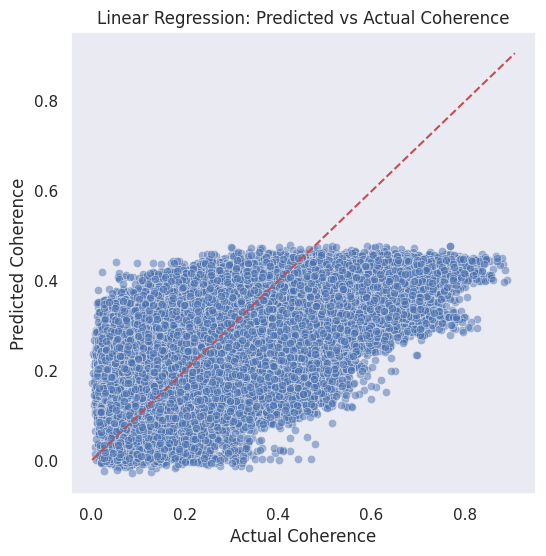

               Feature  Coefficient
11            max_temp    -4.32e-02
21        total_posdeg    -3.10e-02
23          total_rain    -2.67e-02
22        total_precip    -2.39e-02
0       acq_day_precip     2.25e-02
6   diurnal_temp_range     2.08e-02
12            max_wind    -1.97e-02
24          total_snow    -1.85e-02
8   freeze_thaw_cycles     1.62e-02
3           cover_2019     1.45e-02
20       temp_diff_acq     9.73e-03
13           mean_temp     8.76e-03
9   hours_blowing_snow     8.57e-03
2          canopy_2019    -5.51e-03
7            elevation    -4.98e-03
5       density_change    -4.87e-03
18           swe_accum    -3.96e-03
19           temp_diff     3.95e-03
1               aspect    -3.89e-03
16          snow_class     2.74e-03
10     incidence_angle    -1.03e-03
4                curve     9.89e-04
14           mean_wind     4.59e-04
17          swe_ablate    -3.44e-04
15               slope     3.24e-04


In [15]:
# linear model with sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# get column index of coherence 
c_idx = list(data.data_vars).index('coherence')
all_other_idxs = [i for i in range(len(data.data_vars)) if i != c_idx]

# Define features and target
X = data_clean[:, all_other_idxs]  # all variables except coherence
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R² score for linear regression: {r2:.3f}')
print(f'RMSE for linear regression: {rmse:.3f}')
print(f'MSE for linear regression: {mse:.3f}')

# Plot predicted vs actual coherence
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Linear Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()

# Feature importance (coefficients) from linear regression
feature_names = [v for v in data.data_vars if v != 'coherence']
coefficients = model.coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print(coef_df[['Feature', 'Coefficient']])


R² score for linear regression: 0.243
RMSE for linear regression: 0.133
MSE for linear regression: 0.018


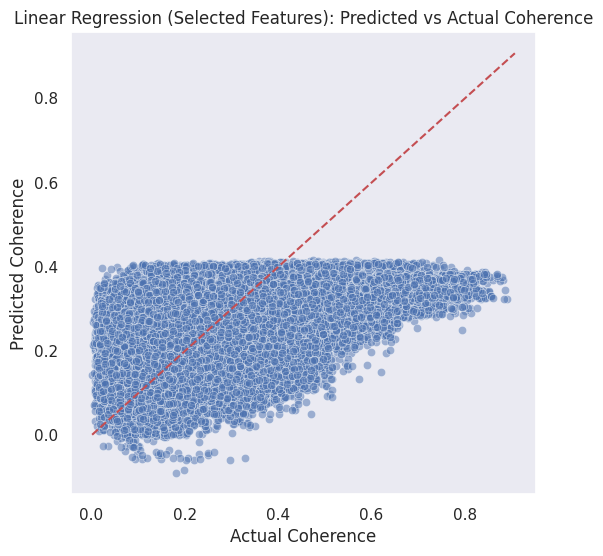

In [16]:
feature_subset = ['elevation', 
                  'slope', 
                  'aspect', 
                  'swe_accum', 
                  'cover_2019', 
                  'total_posdeg', 
                  'mean_temp',
                  'max_wind']
subset_idxs = [list(data.data_vars).index(var) for var in feature_subset]

# Define features and target
X = data_clean[:, subset_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R² score for linear regression: {r2:.3f}')
print(f'RMSE for linear regression: {rmse:.3f}')
print(f'MSE for linear regression: {mse:.3f}')

# Plot predicted vs actual coherence
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Linear Regression (Selected Features): Predicted vs Actual Coherence')
plt.grid()
plt.show()

# Simple decision tree

R² score for decision tree regression: 0.493
RMSE for decision tree regression: 0.109
MSE for decision tree regression: 0.012


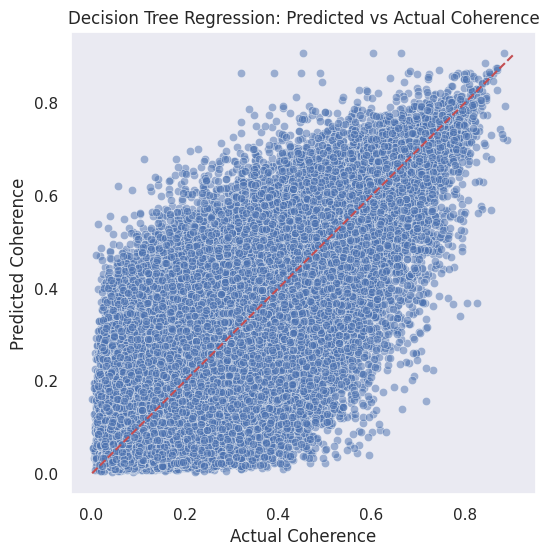

               Feature  Importance
22        total_precip    2.00e-01
23          total_rain    1.52e-01
7            elevation    8.72e-02
1               aspect    6.33e-02
20       temp_diff_acq    5.63e-02
15               slope    4.79e-02
10     incidence_angle    4.07e-02
4                curve    3.93e-02
5       density_change    3.85e-02
21        total_posdeg    3.82e-02
11            max_temp    3.52e-02
2          canopy_2019    3.29e-02
24          total_snow    2.93e-02
18           swe_accum    2.87e-02
14           mean_wind    1.45e-02
12            max_wind    1.42e-02
17          swe_ablate    1.37e-02
9   hours_blowing_snow    1.35e-02
0       acq_day_precip    1.20e-02
3           cover_2019    1.13e-02
16          snow_class    9.21e-03
8   freeze_thaw_cycles    7.99e-03
6   diurnal_temp_range    6.90e-03
19           temp_diff    5.14e-03
13           mean_temp    1.10e-03


In [17]:
# make a decision tree regressor and evaluate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# redefine features and target for decision tree
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_tree = tree_model.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f'R² score for decision tree regression: {r2_tree:.3f}')
print(f'RMSE for decision tree regression: {rmse_tree:.3f}')
print(f'MSE for decision tree regression: {mse_tree:.3f}')

# Plot predicted vs actual coherence for decision tree
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Decision Tree Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()  

# Feature importance from decision tree
feature_names = [v for v in data.data_vars if v != 'coherence']
importances = tree_model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)


# Random forest

R² score for random forest regression: 0.742
RMSE for random forest regression: 0.078
MSE for random forest regression: 0.006


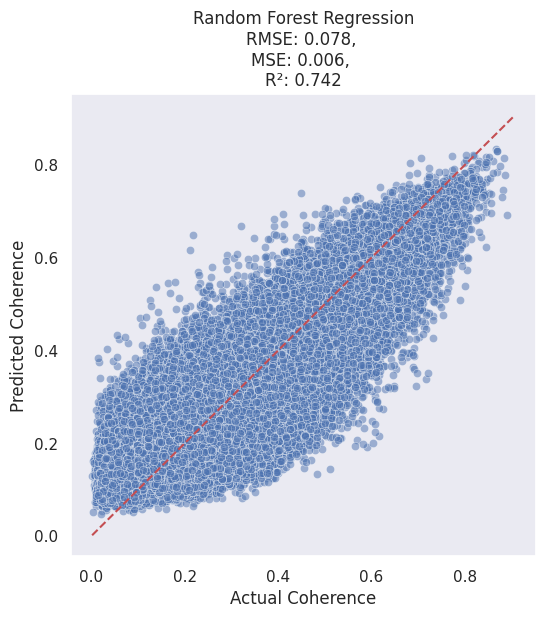

               Feature  Importance
22        total_precip    2.05e-01
23          total_rain    1.56e-01
7            elevation    8.16e-02
1               aspect    6.18e-02
20       temp_diff_acq    5.54e-02
15               slope    4.95e-02
10     incidence_angle    4.35e-02
4                curve    4.18e-02
5       density_change    3.74e-02
11            max_temp    3.60e-02
2          canopy_2019    3.35e-02
18           swe_accum    2.98e-02
21        total_posdeg    2.43e-02
24          total_snow    2.43e-02
14           mean_wind    1.59e-02
17          swe_ablate    1.49e-02
9   hours_blowing_snow    1.42e-02
12            max_wind    1.38e-02
8   freeze_thaw_cycles    1.30e-02
3           cover_2019    1.11e-02
0       acq_day_precip    8.54e-03
6   diurnal_temp_range    8.31e-03
16          snow_class    8.20e-03
19           temp_diff    6.45e-03
13           mean_temp    5.37e-03


In [18]:
# make a random forest model and evaluate
from sklearn.ensemble import RandomForestRegressor

# redefine features and target for random forest
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train random forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'R² score for random forest regression: {r2_rf:.3f}')
print(f'RMSE for random forest regression: {rmse_rf:.3f}')
print(f'MSE for random forest regression: {mse_rf:.3f}')

# Plot predicted vs actual coherence for random forest
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title(f'Random Forest Regression\nRMSE: {rmse_rf:.3f}, \nMSE: {mse_rf:.3f}, \nR²: {r2_rf:.3f}')
plt.grid()
plt.show() 

# Feature importance from random forest
feature_names = [v for v in data.data_vars if v != 'coherence']
importances_rf = rf_model.feature_importances_
importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
importance_rf_df = importance_rf_df.sort_values('Importance', ascending=False)
print(importance_rf_df)

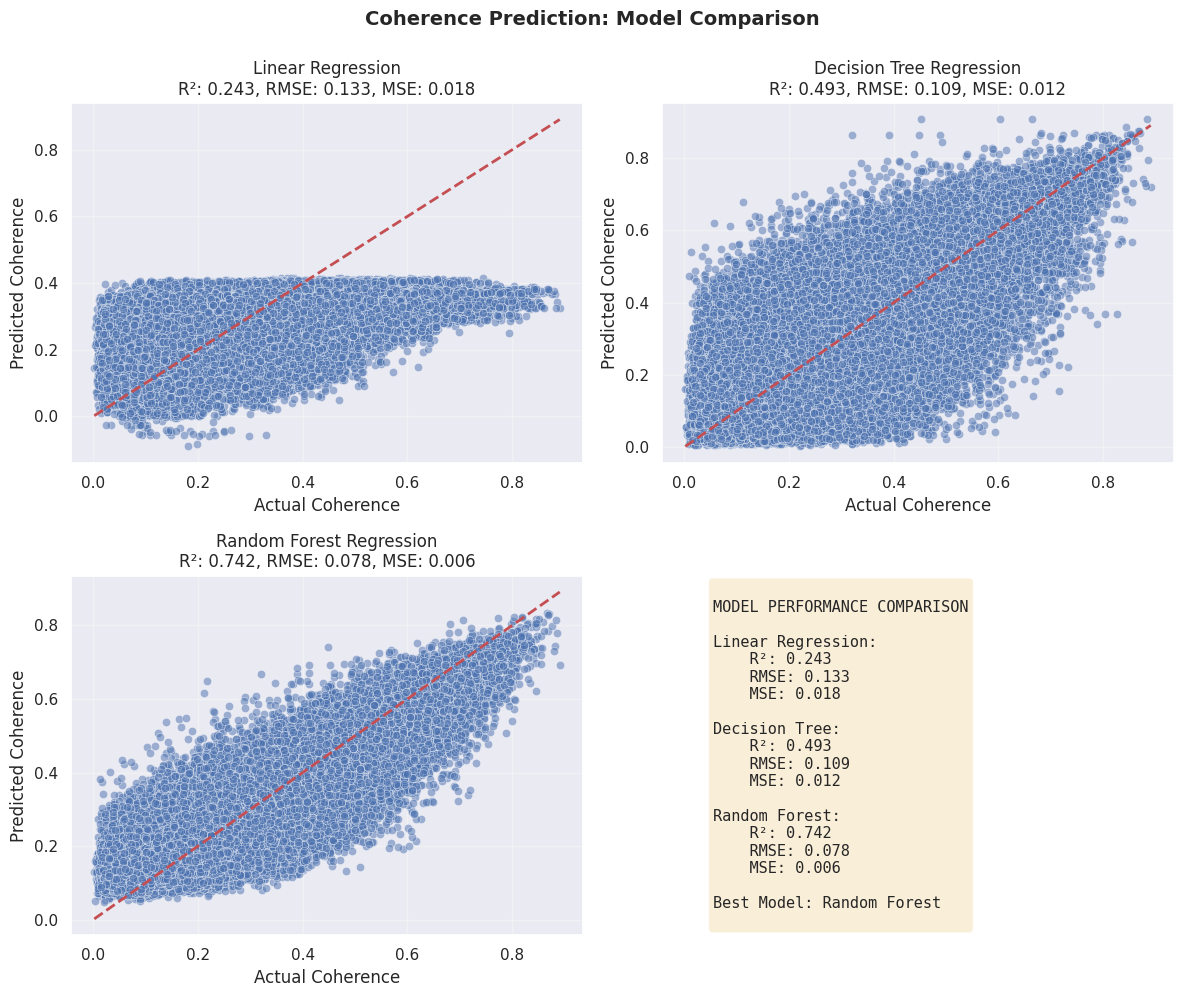

In [22]:
# Create a figure with 4 subplots for model comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1. Linear Regression
ax = axes[0]
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Linear Regression\nR²: {r2:.3f}, RMSE: {rmse:.3f}, MSE: {mse:.3f}')
ax.grid(True, alpha=0.3)

# 2. Decision Tree
ax = axes[1]
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Decision Tree Regression\nR²: {r2_tree:.3f}, RMSE: {rmse_tree:.3f}, MSE: {mse_tree:.3f}')
ax.grid(True, alpha=0.3)

# 3. Random Forest
ax = axes[2]
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Random Forest Regression\nR²: {r2_rf:.3f}, RMSE: {rmse_rf:.3f}, MSE: {mse_rf:.3f}')
ax.grid(True, alpha=0.3)

# 4. Model Comparison Summary (text plot)
ax = axes[3]
ax.axis('off')
summary_text = f"""
MODEL PERFORMANCE COMPARISON

Linear Regression:
    R²: {r2:.3f}
    RMSE: {rmse:.3f}
    MSE: {mse:.3f}

Decision Tree:
    R²: {r2_tree:.3f}
    RMSE: {rmse_tree:.3f}
    MSE: {mse_tree:.3f}

Random Forest:
    R²: {r2_rf:.3f}
    RMSE: {rmse_rf:.3f}
    MSE: {mse_rf:.3f}

Best Model: Random Forest
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Coherence Prediction: Model Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

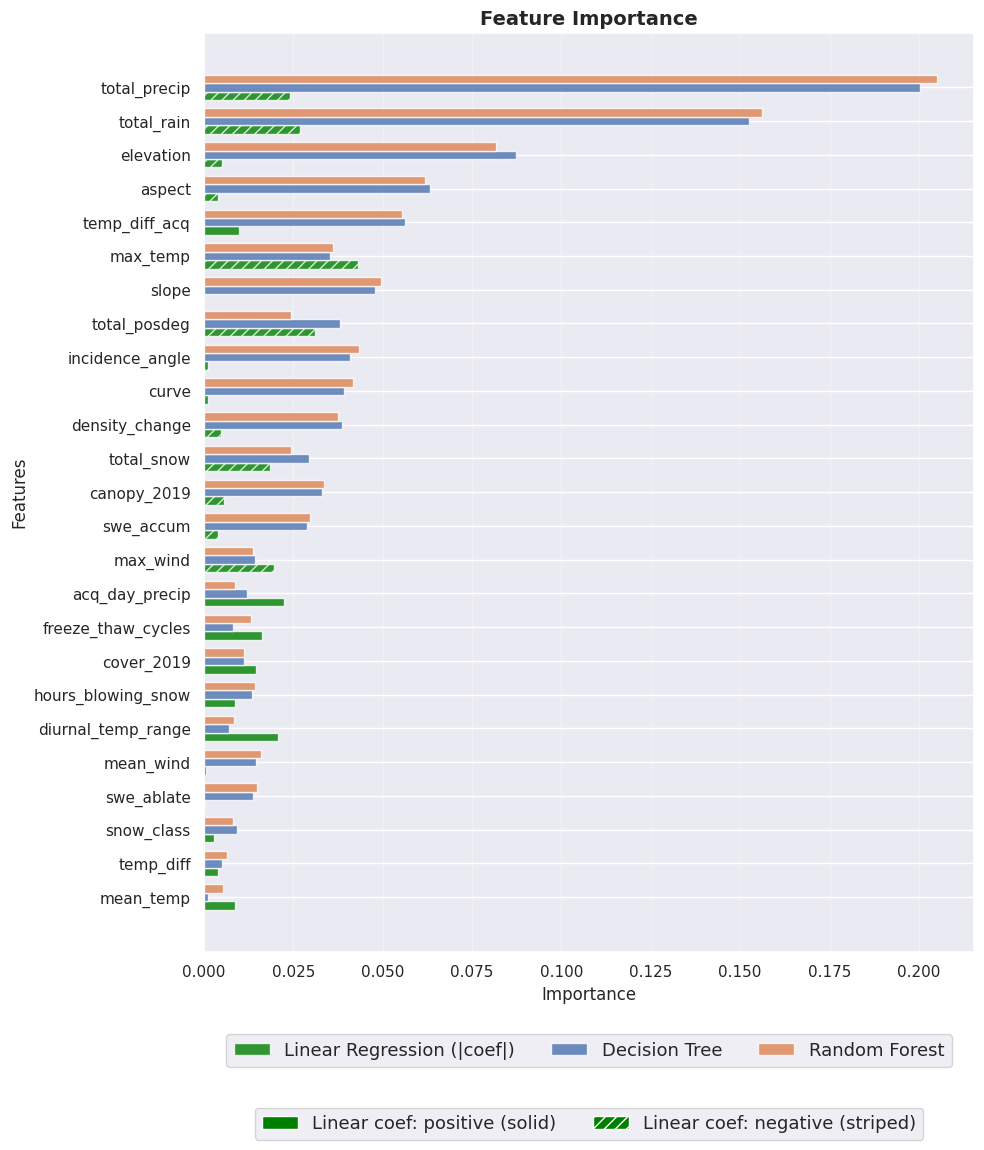


Feature Importance Comparison (sorted by mean importance):
           Feature  Linear Coef Linear Sign  Linear Regression  Decision Tree  Random Forest  Mean Importance
         mean_temp     8.76e-03    Positive           8.76e-03       1.10e-03       5.37e-03         5.08e-03
         temp_diff     3.95e-03    Positive           3.95e-03       5.14e-03       6.45e-03         5.18e-03
        snow_class     2.74e-03    Positive           2.74e-03       9.21e-03       8.20e-03         6.72e-03
        swe_ablate    -3.44e-04    Negative           3.44e-04       1.37e-02       1.49e-02         9.68e-03
         mean_wind     4.59e-04    Positive           4.59e-04       1.45e-02       1.59e-02         1.03e-02
diurnal_temp_range     2.08e-02    Positive           2.08e-02       6.90e-03       8.31e-03         1.20e-02
hours_blowing_snow     8.57e-03    Positive           8.57e-03       1.35e-02       1.42e-02         1.21e-02
        cover_2019     1.45e-02    Positive           1.45e-

In [23]:
# Create a comparison of feature importances across models
# Keep signed linear coefficients for direction, and absolute values for ranking
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Coef': coefficients,
    'Linear Regression': np.abs(coefficients),
    'Decision Tree': importances,
    'Random Forest': importances_rf
})

# Add sign label for linear model direction
comparison_df['Linear Sign'] = np.where(comparison_df['Linear Coef'] >= 0, 'Positive', 'Negative')

# Calculate mean importance across all models to order features
comparison_df['Mean Importance'] = comparison_df[['Linear Regression', 'Decision Tree', 'Random Forest']].mean(axis=1)
comparison_df = comparison_df.sort_values('Mean Importance', ascending=True)

# Create horizontal bar plot for easier feature name readability
fig, ax = plt.subplots(figsize=(10, 12))

x = np.arange(len(comparison_df))
width = 0.25

# Draw linear bars with one color; use fill pattern to indicate sign
linear_bars = ax.barh(
    x - width,
    comparison_df['Linear Regression'],
    width,
    color='green',
    # edgecolor='black',
    alpha=0.8,
    label='Linear Regression (|coef|)'
)

# Solid hatch for positive, striped hatch for negative
for bar, coef in zip(linear_bars, comparison_df['Linear Coef']):
    bar.set_hatch('' if coef >= 0 else '///')

ax.barh(x, comparison_df['Decision Tree'], width, label='Decision Tree', alpha=0.8)
ax.barh(x + width, comparison_df['Random Forest'], width, label='Random Forest', alpha=0.8)

# Sign legend for linear regression fill style
from matplotlib.patches import Patch
sign_legend = [
    Patch(facecolor='green', hatch='', label='Linear coef: positive (solid)'),
    Patch(facecolor='green', hatch='///', label='Linear coef: negative (striped)')
]

ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(comparison_df['Feature'])

# Stack both legends at the bottom and increase legend text size
legend_models = ax.legend(
    fontsize=13,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=True
)
ax.add_artist(legend_models)
ax.legend(
    handles=sign_legend,
    fontsize=13,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True
)

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# Print the comparison table with sign information
print("\nFeature Importance Comparison (sorted by mean importance):")
print(comparison_df[['Feature', 'Linear Coef', 'Linear Sign', 'Linear Regression', 'Decision Tree', 'Random Forest', 'Mean Importance']].to_string(index=False))